## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
plt.rcParams['figure.dpi'] = 110
%matplotlib inline

## Loading Data

In [2]:
df = pd.read_csv('US_Accidents_March23.csv')

In [3]:
# Selecting Columns to KEEP

required_cols = [
    'Severity', 'Start_Time', 'Start_Lat', 'Start_Lng',
    'City', 'County', 'State', 'Distance(mi)',
    'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)',
    'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition',
    'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit',
    'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming',
    'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset'
]

df = df[required_cols].copy()
print(df.shape)

(7728394, 30)


In [4]:
df.columns.values

<ArrowStringArray>
[         'Severity',        'Start_Time',         'Start_Lat',
         'Start_Lng',              'City',            'County',
             'State',      'Distance(mi)',    'Temperature(F)',
       'Humidity(%)',      'Pressure(in)',    'Visibility(mi)',
    'Wind_Direction',   'Wind_Speed(mph)', 'Precipitation(in)',
 'Weather_Condition',           'Amenity',              'Bump',
          'Crossing',          'Give_Way',          'Junction',
           'No_Exit',           'Railway',        'Roundabout',
           'Station',              'Stop',   'Traffic_Calming',
    'Traffic_Signal',      'Turning_Loop',    'Sunrise_Sunset']
Length: 30, dtype: str

In [5]:
df.head()

,Severity,Start_Time,Start_Lat,Start_Lng,City,County,State,Distance(mi),Temperature(F),Humidity(%),...,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset
0,3,2016-02-08 05:46:00,39.865147,-84.058723,Dayton,Montgomery,OH,0.01,36.9,91.0,...,False,False,False,False,False,False,False,False,False,Night
1,2,2016-02-08 06:07:59,39.928059,-82.831184,Reynoldsburg,Franklin,OH,0.01,37.9,100.0,...,False,False,False,False,False,False,False,False,False,Night
2,2,2016-02-08 06:49:27,39.063148,-84.032608,Williamsburg,Clermont,OH,0.01,36.0,100.0,...,False,False,False,False,False,False,False,True,False,Night
3,3,2016-02-08 07:23:34,39.747753,-84.205582,Dayton,Montgomery,OH,0.01,35.1,96.0,...,False,False,False,False,False,False,False,False,False,Night
4,2,2016-02-08 07:39:07,39.627781,-84.188354,Dayton,Montgomery,OH,0.01,36.0,89.0,...,False,False,False,False,False,False,False,True,False,Day


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 30 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Severity           int64  
 1   Start_Time         str    
 2   Start_Lat          float64
 3   Start_Lng          float64
 4   City               str    
 5   County             str    
 6   State              str    
 7   Distance(mi)       float64
 8   Temperature(F)     float64
 9   Humidity(%)        float64
 10  Pressure(in)       float64
 11  Visibility(mi)     float64
 12  Wind_Direction     str    
 13  Wind_Speed(mph)    float64
 14  Precipitation(in)  float64
 15  Weather_Condition  str    
 16  Amenity            bool   
 17  Bump               bool   
 18  Crossing           bool   
 19  Give_Way           bool   
 20  Junction           bool   
 21  No_Exit            bool   
 22  Railway            bool   
 23  Roundabout         bool   
 24  Station            bool   
 25  Stop               bool   
 2

## Cleaning Data

In [7]:
df.isnull().sum()

Severity                   0
Start_Time                 0
Start_Lat                  0
Start_Lng                  0
City                     253
County                     0
State                      0
Distance(mi)               0
Temperature(F)        163853
Humidity(%)           174144
Pressure(in)          140679
Visibility(mi)        177098
Wind_Direction        175206
Wind_Speed(mph)       571233
Precipitation(in)    2203586
Weather_Condition     173459
Amenity                    0
Bump                       0
Crossing                   0
Give_Way                   0
Junction                   0
No_Exit                    0
Railway                    0
Roundabout                 0
Station                    0
Stop                       0
Traffic_Calming            0
Traffic_Signal             0
Turning_Loop               0
Sunrise_Sunset         23246
dtype: int64

In [8]:
# Regional imputation for weather columns (better than global median)
weather_cols = ['Temperature(F)', 'Humidity(%)', 'Pressure(in)',
                 'Visibility(mi)', 'Wind_Speed(mph)']
for col in weather_cols:
    df[col] = df.groupby('State')[col].transform(lambda x: x.fillna(x.median()))

In [9]:
df['Precipitation(in)'] = df['Precipitation(in)'].fillna(0)
df['Wind_Direction'] = df['Wind_Direction'].fillna(df['Wind_Direction'].mode()[0])
df['Weather_Condition'] = df['Weather_Condition'].fillna('Unknown')

In [10]:
# Drop rows with negligible missingness
df = df.dropna(subset=['City', 'Sunrise_Sunset'])

In [11]:
print(df.isnull().sum())

Severity             0
Start_Time           0
Start_Lat            0
Start_Lng            0
City                 0
County               0
State                0
Distance(mi)         0
Temperature(F)       0
Humidity(%)          0
Pressure(in)         0
Visibility(mi)       0
Wind_Direction       0
Wind_Speed(mph)      0
Precipitation(in)    0
Weather_Condition    0
Amenity              0
Bump                 0
Crossing             0
Give_Way             0
Junction             0
No_Exit              0
Railway              0
Roundabout           0
Station              0
Stop                 0
Traffic_Calming      0
Traffic_Signal       0
Turning_Loop         0
Sunrise_Sunset       0
dtype: int64


## Feature Engineering

In [12]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df = df.dropna(subset=['Start_Time'])

df['Hour'] = df['Start_Time'].dt.hour
df['DayOfWeek'] = df['Start_Time'].dt.day_name()
df['Month'] = df['Start_Time'].dt.month_name()
df['Year'] = df['Start_Time'].dt.year
df['Is_Weekend'] = df['Start_Time'].dt.dayofweek >= 5

def time_bucket(h):
    if 5 <= h < 12: return 'Morning'
    elif 12 <= h < 17: return 'Afternoon'
    elif 17 <= h < 21: return 'Evening'
    else: return 'Night'

df['Time_of_Day'] = df['Hour'].apply(time_bucket)

## Time-pattern EDA

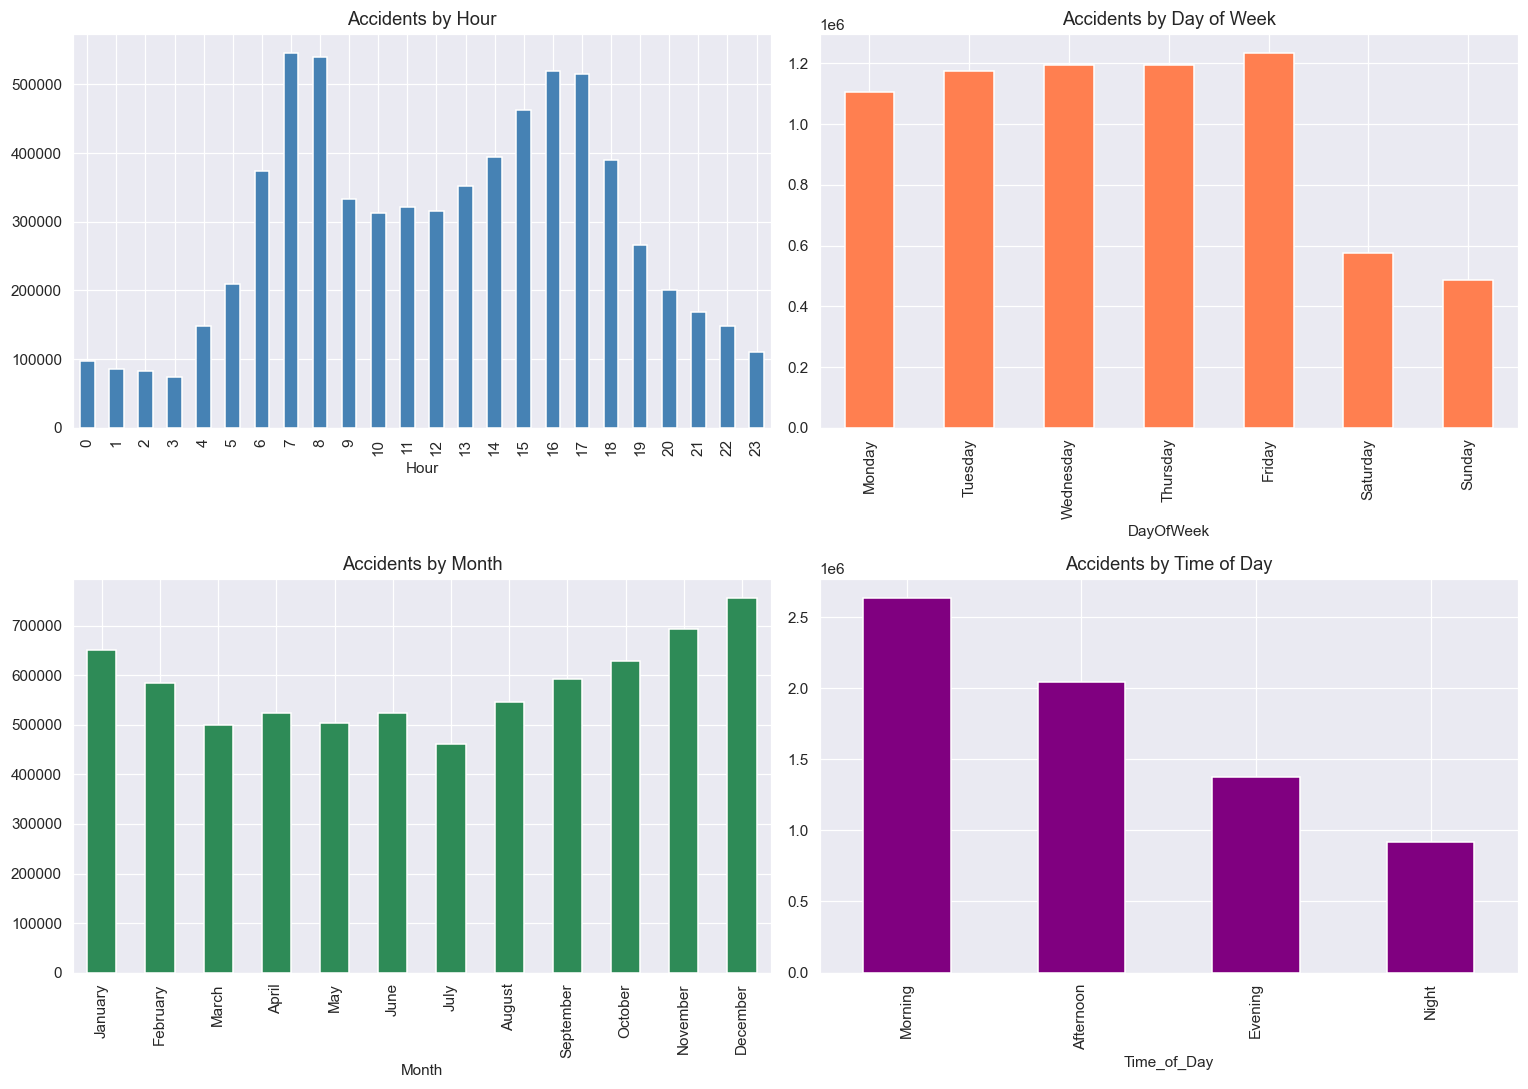

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df['Hour'].value_counts().sort_index().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Accidents by Hour')

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['DayOfWeek'].value_counts().reindex(order).plot(kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Accidents by Day of Week')

month_order = ['January','February','March','April','May','June','July',
               'August','September','October','November','December']
df['Month'].value_counts().reindex(month_order).plot(kind='bar', ax=axes[1,0], color='seagreen')
axes[1,0].set_title('Accidents by Month')

df['Time_of_Day'].value_counts().plot(kind='bar', ax=axes[1,1], color='purple')
axes[1,1].set_title('Accidents by Time of Day')

plt.tight_layout()
plt.savefig('time_patterns.png', dpi=150)
plt.show()

## Weather impact

C:\Users\Raj\AppData\Local\Temp\ipykernel_20500\816306180.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_weather.values, y=top_weather.index, palette='mako')


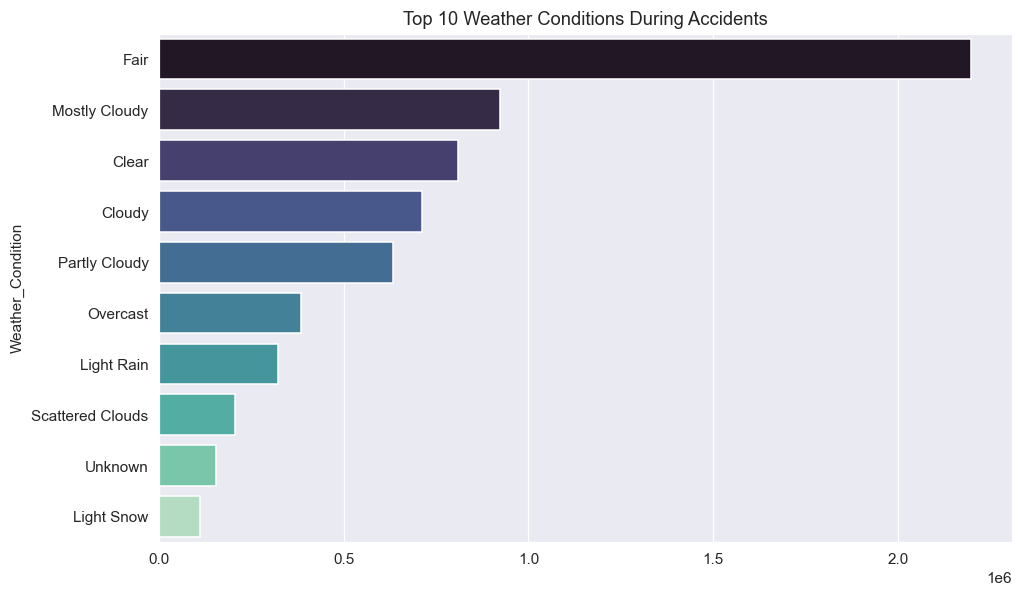

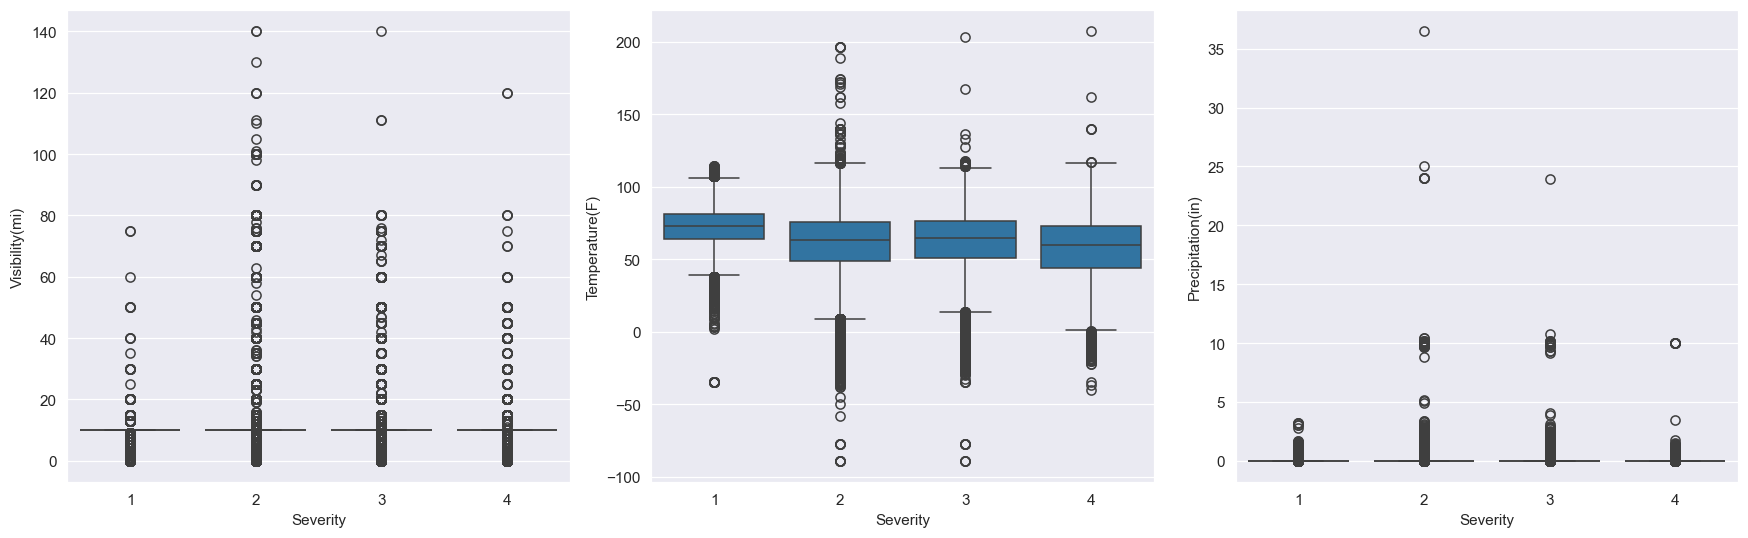

In [22]:
# Top weather conditions by accident count
top_weather = df['Weather_Condition'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_weather.values, y=top_weather.index, palette='mako')
plt.title('Top 10 Weather Conditions During Accidents')
plt.savefig('weather.png', dpi=150)
plt.show()

# Severity vs continuous weather variables
fig, axes = plt.subplots(1, 3, figsize=(16,5))
sns.boxplot(x='Severity', y='Visibility(mi)', data=df, ax=axes[0])
sns.boxplot(x='Severity', y='Temperature(F)', data=df, ax=axes[1])
sns.boxplot(x='Severity', y='Precipitation(in)', data=df, ax=axes[2])

plt.tight_layout()
plt.savefig('weather_impact.png', dpi=150)
plt.show()

## Road condition (boolean features)

            Feature  Accident_Rate_When_True  Avg_Severity_When_True
4          Junction                 0.074515                2.322042
3          Give_Way                 0.004905                2.184159
6           Railway                 0.008835                2.167289
10  Traffic_Calming                 0.000979                2.139215
5           No_Exit                 0.002544                2.120896
1              Bump                 0.000445                2.105738
11   Traffic_Signal                 0.156080                2.090993
8           Station                 0.026054                2.081869
9              Stop                 0.027877                2.077487
7        Roundabout                 0.000032                2.077273
0           Amenity                 0.012558                2.073233
2          Crossing                 0.115876                2.067011
12     Turning_Loop                 0.000000                     NaN


C:\Users\Raj\AppData\Local\Temp\ipykernel_20500\1976354823.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Avg_Severity_When_True', y='Feature', data=impact, palette='rocket')


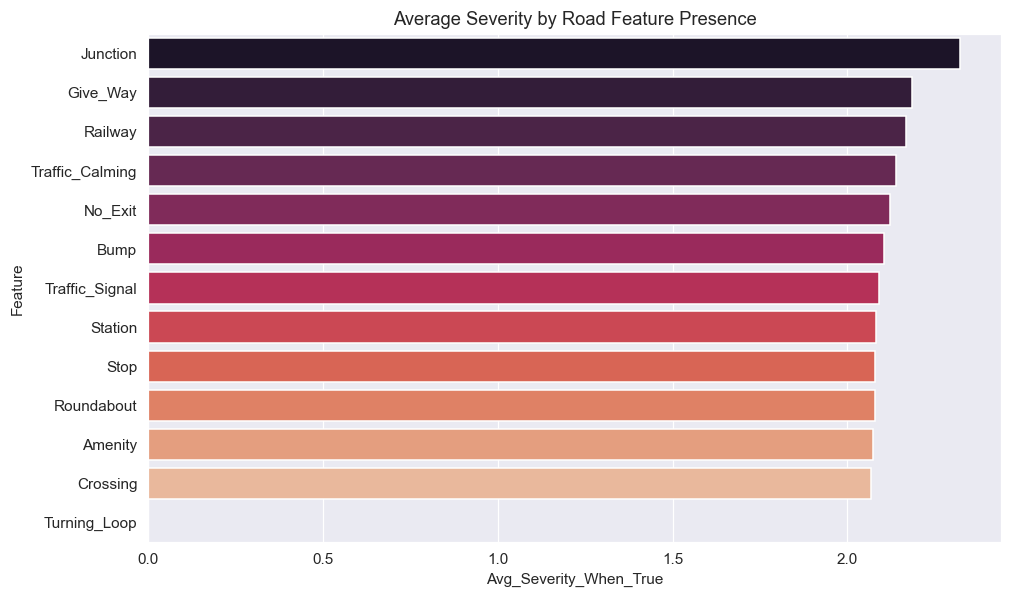

In [23]:
bool_cols = ['Amenity','Bump','Crossing','Give_Way','Junction','No_Exit',
             'Railway','Roundabout','Station','Stop','Traffic_Calming',
             'Traffic_Signal','Turning_Loop']

impact = pd.DataFrame({
    'Feature': bool_cols,
    'Accident_Rate_When_True': [df[df[c]==True].shape[0] / df.shape[0] for c in bool_cols],
    'Avg_Severity_When_True': [df[df[c]==True]['Severity'].mean() for c in bool_cols]
}).sort_values('Avg_Severity_When_True', ascending=False)

print(impact)

plt.figure(figsize=(10,6))
sns.barplot(x='Avg_Severity_When_True', y='Feature', data=impact, palette='rocket')
plt.title('Average Severity by Road Feature Presence')
plt.savefig('road_condt.png', dpi=150)
plt.show()

## Hotspot visualization (handle scale carefully)

In [16]:
import folium
from folium.plugins import HeatMap

# Sample for performance — full 7.7M points will crash the browser
sample = df.sample(n=100000, random_state=42)

m = folium.Map(location=[39.8, -98.6], zoom_start=4, tiles='CartoDB dark_matter')
HeatMap(data=sample[['Start_Lat','Start_Lng']].values, radius=6, blur=8).add_to(m)
m.save('accident_hotspots.html')

# City-level top hotspots table
top_cities = df.groupby(['City','State']).size().sort_values(ascending=False).head(15)
print(top_cities)

# State choropleth
state_counts = df['State'].value_counts().reset_index()
state_counts.columns = ['State','Count']

City         State
Houston      TX       159799
Miami        FL       156414
Los Angeles  CA       142452
Charlotte    NC       130259
Dallas       TX       120413
Orlando      FL        93578
Austin       TX        91376
Raleigh      NC        79480
Nashville    TN        66877
Baton Rouge  LA        66036
Atlanta      GA        63643
Sacramento   CA        59878
Phoenix      AZ        49461
San Diego    CA        49363
Minneapolis  MN        46911
dtype: int64


In [17]:
print(df.shape[0])  # total rows
print(top_cities.sum())  # sum of top 15 cities

6967668
1375940


## Contributing factors — correlation & importance

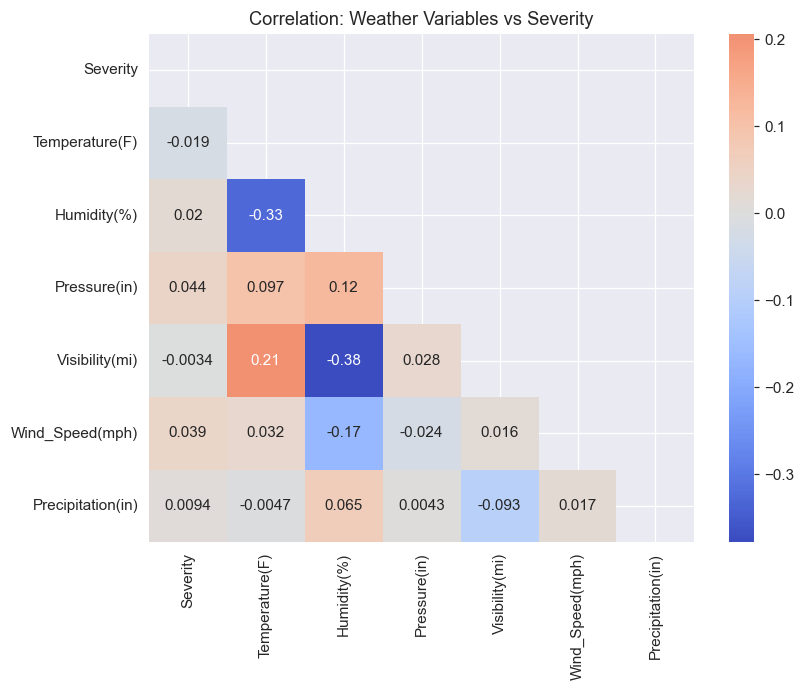

In [24]:
# Correlation heatmap
corr_cols = ['Severity','Temperature(F)','Humidity(%)','Pressure(in)',
             'Visibility(mi)','Wind_Speed(mph)','Precipitation(in)']
plt.figure(figsize=(8,6))
mask = np.triu(np.ones_like(df[corr_cols].corr(), dtype=bool))
sns.heatmap(df[corr_cols].corr(), mask=mask, annot=True, cmap='coolwarm', center=0)

plt.title('Correlation: Weather Variables vs Severity')
plt.savefig('correlation.png', dpi=150)
plt.show()

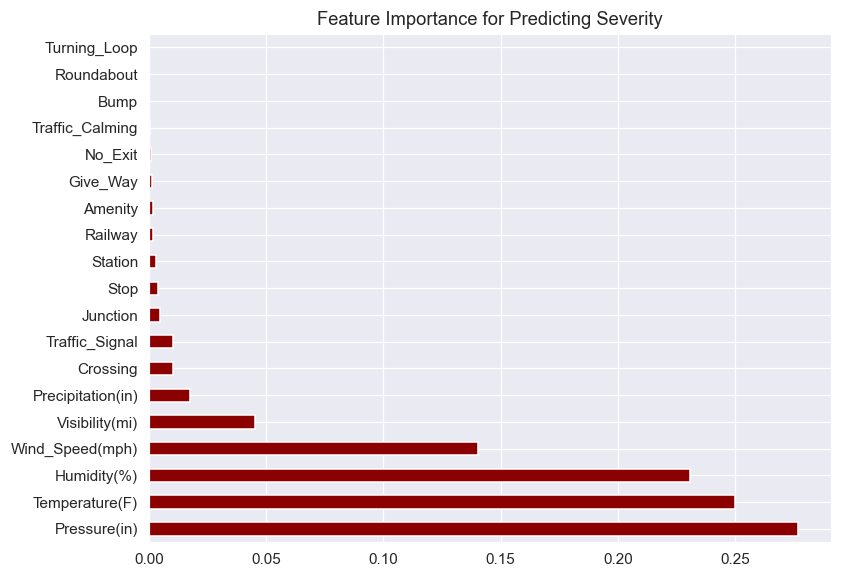

In [26]:
# Quick feature importance via Random Forest (mirrors your DS_03 approach)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

model_df = df[corr_cols + bool_cols].copy()
X = model_df.drop('Severity', axis=1)
y = model_df['Severity']

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X.sample(200000, random_state=42), y.sample(200000, random_state=42))  # subsample for speed

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot(kind='barh', figsize=(8,6), color='darkred')

plt.title('Feature Importance for Predicting Severity')
plt.savefig('feature_importance.png', dpi=150)
plt.show()

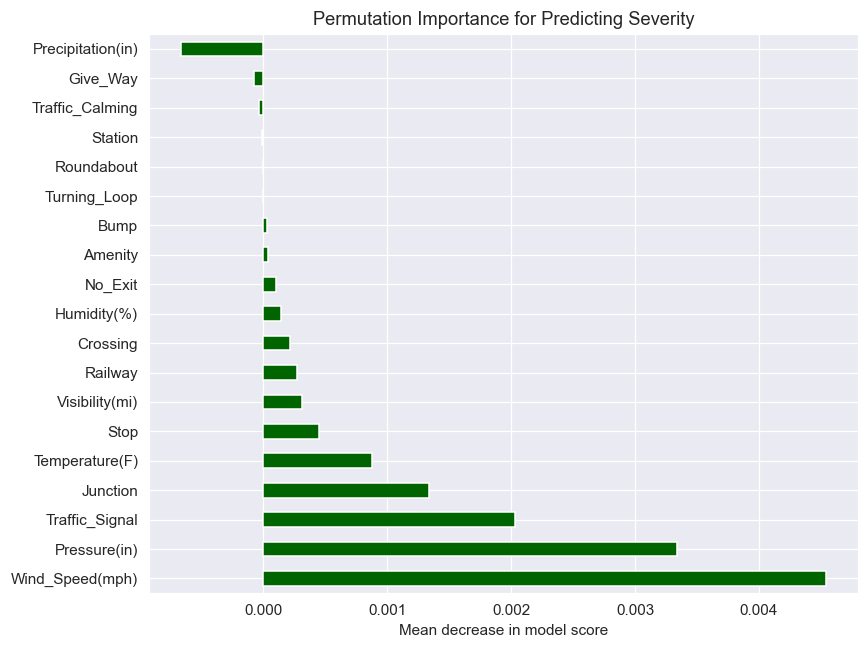

In [27]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_sub = X.sample(200000, random_state=42)
y_sub = y.loc[X_sub.index]  # aligned via index instead of a second independent .sample()

X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

perm_result = permutation_importance(
    rf, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1
)

perm_importances = pd.Series(
    perm_result.importances_mean, index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
perm_importances.plot(kind='barh', color='darkgreen')
plt.title('Permutation Importance for Predicting Severity')
plt.xlabel('Mean decrease in model score')

plt.tight_layout()
plt.savefig('permutation_feature_importance.png', dpi=150)
plt.show()